# HF TDOA Analysis - Figure 8

This notebook creates Figure 8: Same Path Different Frequencies.

Shows layer height measurements from AB5YO on both 40m (5.3 MHz) and 60m (7.3 MHz) bands over the same path.

In [1]:
import datetime
import matplotlib.pyplot as plt
import hf_tdoa as tdoa

%matplotlib inline

# Setup plotting style
tdoa.setup_plotting_style()

## Create Figure 8: AB5YO 40m and 60m Subplots

Figure 8 shows layer height measurements from AB5YO on both 40m (5.3 MHz, top panel) and 60m (7.3 MHz, bottom panel) bands, demonstrating how different frequencies over the same path produce different height profiles.

/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:655: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tdoa_df = pd.read_csv(csv_path, parse_dates=['utc'], comment='#')
/Users/r01344106/code/frontiers/HF-TDOA-Frontiers-2025/hf_tdoa/hf_tdoa_lib.py:655: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tdoa_df = pd.read_csv(csv_path, parse_dates=['utc'], comment='#')


Figure saved to: fig_08.jpg


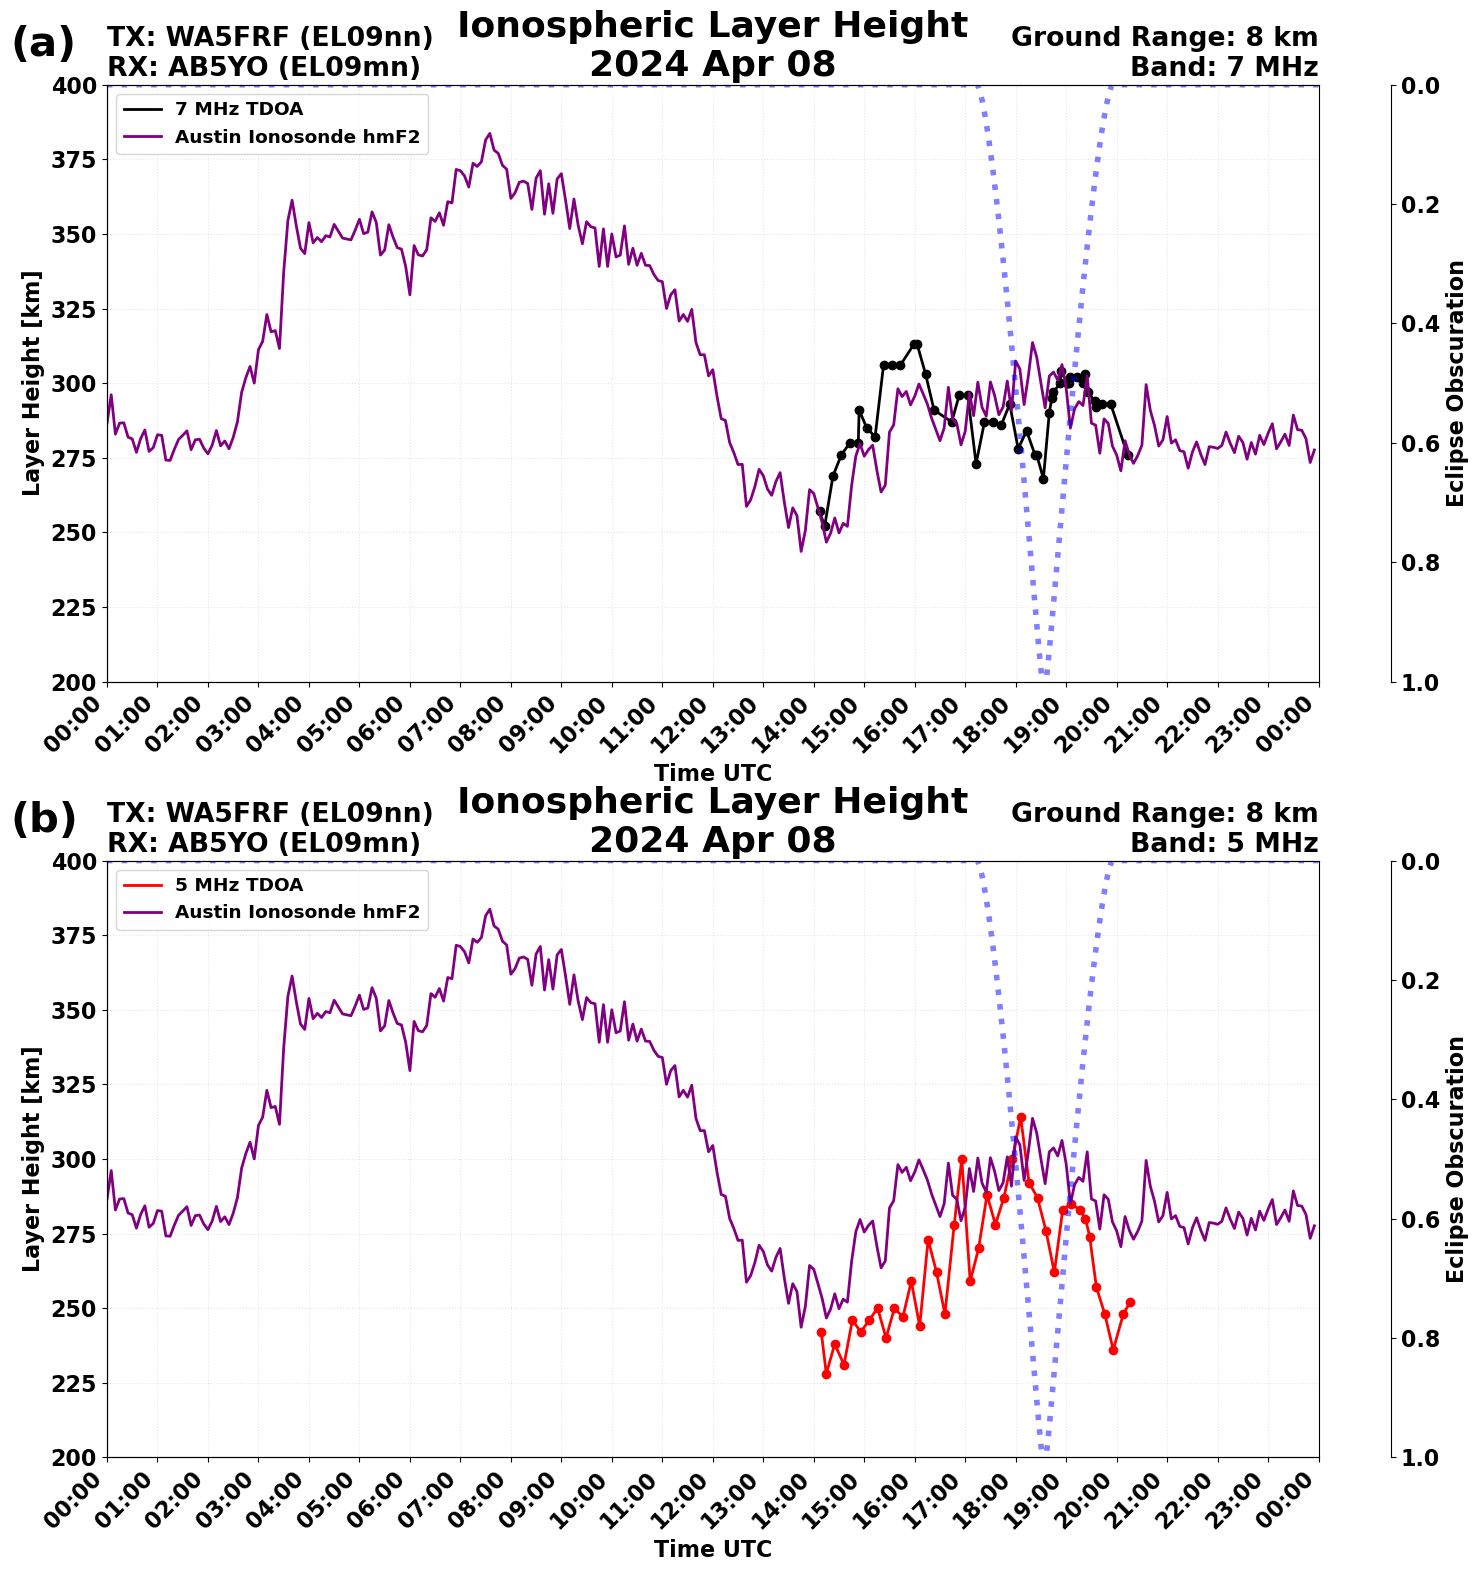

In [2]:
# Create PathInfo objects for titles
path_info_40m = tdoa.PathInfo('TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m')
path_info_60m = tdoa.PathInfo('TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m')

# Get solar coordinates for eclipse overlay
solar_lat, solar_lon = path_info_40m.get_midpoint()

# Date for titles
date = datetime.datetime(2024, 4, 8)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 16))

# Set time limits for consistent x-axis across subplots - full day
xlim = (datetime.datetime(2024, 4, 8), datetime.datetime(2024, 4, 9))
ylim = (200, 400)

# Panel (a): 40m (7 MHz) data
tdoa.overlay_tdoa_csv(
    ax1,
    csv_path='../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-40m_manual_analysis.csv',
    model_coeffs=(1, 0),  # No transformation needed - data already in km
    overlay_manual=True,
    overlay_autocorr=False,
    manual_label=f'{path_info_40m.band_str} TDOA',
    manual_color='black',
    manual_linestyle='solid'
)

tdoa.overlay_ionosonde(
    ax1,
    csv_path='../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv',
    overlay_hmF2=True,
    overlay_hmE=False,
    label='Austin Ionosonde',
    hmF2_color='purple'
)

# Add solar elevation and eclipse overlay for panel (a)
from hf_tdoa import solarContext
solar_ts_1 = solarContext.solarTimeseries(
    sTime=xlim[0],
    eTime=xlim[1],
    lat=solar_lat,
    lon=solar_lon
)
# solar_ts_1.overlaySolarElevation(ax1)
solar_ts_1.overlayEclipse(ax1)

# Format x-axis with datetime formatting
from matplotlib import dates as mdates
myFmt = mdates.DateFormatter('%H:%M')
ax1.xaxis.set_major_formatter(myFmt)
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))

ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_ylabel('Layer Height [km]')
ax1.set_xlabel('Time UTC')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', fontsize='small')

# Add title using the library's formatting
tdoa.title_from_pfx(ax1, path_info_40m, date=date, center_title='Ionospheric Layer Height')

# Add subplot label
ax1.text(-0.08, 1.100, '(a)', transform=ax1.transAxes,
         fontsize=30, fontweight='bold', va='top', ha='left')

# Panel (b): 60m (5 MHz) data
tdoa.overlay_tdoa_csv(
    ax2,
    csv_path='../data/CSVs/2024-04-08_TX_WA5FRF_EL09nn-RX_AB5YO_EL09mn-60m_manual_analysis.csv',
    model_coeffs=(1, 0),  # No transformation needed - data already in km
    overlay_manual=True,
    overlay_autocorr=False,
    manual_label=f'{path_info_60m.band_str} TDOA',
    manual_color='red',
    manual_linestyle='solid'
)

tdoa.overlay_ionosonde(
    ax2,
    csv_path='../data/CSVs/2024-04-08_AU930_AustinTX_Ionosonde_ManualScaled.csv',
    overlay_hmF2=True,
    overlay_hmE=False,
    label='Austin Ionosonde',
    hmF2_color='purple'
)

# Add solar elevation and eclipse overlay for panel (b)
solar_ts_2 = solarContext.solarTimeseries(
    sTime=xlim[0],
    eTime=xlim[1],
    lat=solar_lat,
    lon=solar_lon
)
# solar_ts_2.overlaySolarElevation(ax2)
solar_ts_2.overlayEclipse(ax2)

# Format x-axis with datetime formatting
ax2.xaxis.set_major_formatter(myFmt)
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))

ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_ylabel('Layer Height [km]')
ax2.set_xlabel('Time UTC')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left', fontsize='small')

# Add title using the library's formatting
tdoa.title_from_pfx(ax2, path_info_60m, date=date, center_title='Ionospheric Layer Height')

# Add subplot label
ax2.text(-0.08, 1.100, '(b)', transform=ax2.transAxes,
         fontsize=30, fontweight='bold', va='top', ha='left')

# Rotate x-axis labels
for ax in [ax1, ax2]:
    for tick_label in ax.get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_horizontalalignment('right')

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)

# Save figure
plt.savefig('fig_08.jpg', dpi=300, bbox_inches='tight', format='jpeg', pil_kwargs={'quality': 95})
print("Figure saved to: fig_08.jpg")

plt.show()